# 05 — Sleep Deprivation and Cognition

This notebook analyzes the relationship between sleep deprivation and cognitive performance using the public CANTAB dataset.

## Objectives

- load the prepared public CANTAB dataset;
- inspect cognitive performance variables;
- compare outcomes between sleep conditions;
- run basic statistical analysis;
- save summary results for interpretation.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_project_root(start=Path.cwd()):
    for path in [start, *start.parents]:
        if (path / "README.md").exists() and (path / "data").exists():
            return path

    raise FileNotFoundError(
        "Project root not found. Make sure README.md and data/ exist."
    )


PROJECT_ROOT = find_project_root()

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
EXTERNAL_DIR = PROJECT_ROOT / "data" / "external"
FIGURES_DIR = PROJECT_ROOT / "figures"

data_path = EXTERNAL_DIR / "SD_CANTAB_DB_public.csv"

if not data_path.exists():
    raise FileNotFoundError(
        f"File not found: {data_path}\n"
        "Place SD_CANTAB_DB_public.csv into data/external/."
    )

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (21, 111)


,Subject ID,DMS Recommended Standard Status,MOT Voice Status,PAL Recommended Standard Status,RTI Five-Choice Status,RVP 3 Targets Status,SWM Recommended standard 2.0 Status,DMSCC,DMSL0SD,DMSL12SD,...,SWMTE4,SWMTE6,SWMTE8,SWMWE,SWMWE4,SWMWE6,SWMWE8,Unnamed: 108,Notes,Unnamed: 110
0,SUBJ001_before,COMPLETED,COMPLETED,COMPLETED,COMPLETED,COMPLETED,COMPLETED,1.00,647.7034,1082.0378,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
1,SUBJ002_before,COMPLETED,COMPLETED,COMPLETED,COMPLETED,COMPLETED,COMPLETED,1.00,254.2214,1088.2416,...,0.0,0.0,6.0,2.0,0.0,0.0,2.0,NaN,NaN,NaN
2,SUBJ003_before,COMPLETED,COMPLETED,COMPLETED,COMPLETED,COMPLETED,COMPLETED,1.00,412.0081,1584.2954,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
3,SUBJ004_before,COMPLETED,COMPLETED,COMPLETED,COMPLETED,NOT_RUN,COMPLETED,1.10,515.5343,294.7749,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,RVP didn't run,NaN
4,SUBJ005_before,COMPLETED,COMPLETED,COMPLETED,COMPLETED,COMPLETED,COMPLETED,1.05,476.0976,1081.0911,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN


In [2]:
df.columns.tolist()

['Subject ID',
 'DMS Recommended Standard Status',
 'MOT Voice Status',
 'PAL Recommended Standard Status',
 'RTI Five-Choice Status',
 'RVP 3 Targets Status',
 'SWM Recommended standard 2.0 Status',
 'DMSCC',
 'DMSL0SD',
 'DMSL12SD',
 'DMSL4SD',
 'DMSLADSD',
 'DMSLSD',
 'DMSLSSD',
 'DMSMDL',
 'DMSMDL0',
 'DMSMDL12',
 'DMSMDL4',
 'DMSMDLAD',
 'DMSMDLS',
 'DMSML',
 'DMSML0',
 'DMSML12',
 'DMSML4',
 'DMSMLAD',
 'DMSMLS',
 'DMSPC',
 'DMSPC0',
 'DMSPC12',
 'DMSPC4',
 'DMSPCAD',
 'DMSPCS',
 'DMSPEGC',
 'DMSPEGE',
 'DMSTC',
 'DMSTC0',
 'DMSTC12',
 'DMSTC4',
 'DMSTCAD',
 'DMSTCS',
 'DMSTE',
 'DMSTEAD',
 'DMSTEC',
 'DMSTECAD',
 'DMSTED',
 'DMSTEDAD',
 'DMSTEP',
 'DMSTEPAD',
 'MOTML',
 'MOTSDL',
 'MOTTC',
 'MOTTE',
 'PALFAMS',
 'PALMETS',
 'PALNPR',
 'PALTA',
 'PALTA2',
 'PALTA4',
 'PALTA6',
 'PALTA8',
 'PALTE',
 'PALTE2',
 'PALTE4',
 'PALTE6',
 'PALTE8',
 'PALTEA',
 'PALTEA2',
 'PALTEA4',
 'PALTEA6',
 'PALTEA8',
 'RTIFESI',
 'RTIFESNR',
 'RTIFESPR',
 'RTIFMDMT',
 'RTIFMDRT',
 'RTIFMMT',
 'RTIF

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Columns: 111 entries, Subject ID to Unnamed: 110
dtypes: float64(103), str(8)
memory usage: 18.3 KB


In [4]:
df.describe(include='all')

,Subject ID,DMS Recommended Standard Status,MOT Voice Status,PAL Recommended Standard Status,RTI Five-Choice Status,RVP 3 Targets Status,SWM Recommended standard 2.0 Status,DMSCC,DMSL0SD,DMSL12SD,...,SWMTE4,SWMTE6,SWMTE8,SWMWE,SWMWE4,SWMWE6,SWMWE8,Unnamed: 108,Notes,Unnamed: 110
count,20,20,20,20,20,20,20,20.000000,20.000000,20.000000,...,20.0,20.000000,20.000000,18.000000,20.0,20.0,20.000000,0.0,1,0.0
unique,20,1,1,1,1,2,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
top,SUBJ001_before,COMPLETED,COMPLETED,COMPLETED,COMPLETED,COMPLETED,COMPLETED,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RVP didn't run,NaN
freq,1,20,20,20,20,19,20,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.072500,829.473945,1111.561390,...,0.0,0.650000,2.050000,0.500000,0.0,0.0,0.450000,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.081878,456.076965,817.410196,...,0.0,1.899446,4.346505,1.689065,0.0,0.0,1.605091,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,252.559500,294.774900,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,505.675125,624.238450,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.050000,687.106000,966.814150,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.112500,1183.618325,1377.792700,...,0.0,0.000000,1.250000,0.000000,0.0,0.0,0.000000,NaN,NaN,NaN


In [5]:
df_clean = df.copy()

drop_cols = ["Unnamed: 108", "Unnamed: 110", "Notes"]
drop_cols = [col for col in drop_cols if col in df_clean.columns]
df_clean = df_clean.drop(columns=drop_cols)

df_clean["condition"] = df_clean["Subject ID"].str.extract(r"_(before|after)$")[0]
df_clean["sleep_deprived"] = (df_clean["condition"] == "after").astype(int)

df_clean["subject_base"] = df_clean["Subject ID"].str.replace(
    r"_(before|after)$",
    "",
    regex=True
)

print(df_clean[["Subject ID", "subject_base", "condition", "sleep_deprived"]].head())
print(df_clean["condition"].value_counts(dropna=False))
print(df_clean.shape)
df = df_clean.copy()

       Subject ID subject_base condition  sleep_deprived
0  SUBJ001_before      SUBJ001    before               0
1  SUBJ002_before      SUBJ002    before               0
2  SUBJ003_before      SUBJ003    before               0
3  SUBJ004_before      SUBJ004    before               0
4  SUBJ005_before      SUBJ005    before               0
condition
before    10
after     10
NaN        1
Name: count, dtype: int64
(21, 111)


In [6]:
status_cols = [c for c in df.columns if 'Status' in c]
non_feature_cols = ['Subject ID', 'condition', 'sleep_deprived', 'subject_base']

feature_df = df.drop(columns=status_cols + [c for c in non_feature_cols if c in df.columns], errors='ignore')

feature_df = feature_df.apply(pd.to_numeric, errors='coerce')

print(feature_df.shape)
feature_df.head()

(21, 101)


,DMSCC,DMSL0SD,DMSL12SD,DMSL4SD,DMSLADSD,DMSLSD,DMSLSSD,DMSMDL,DMSMDL0,DMSMDL12,...,SWMS,SWMS6,SWMTE,SWMTE4,SWMTE6,SWMTE8,SWMWE,SWMWE4,SWMWE6,SWMWE8
0,1.00,647.7034,1082.0378,1519.8841,1106.1289,1068.9469,925.0485,2482.0,2465.0,3007.0,...,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.00,254.2214,1088.2416,1299.9392,971.1181,881.5461,571.6577,1925.5,2039.0,1446.0,...,7.0,3.0,6.0,0.0,0.0,6.0,2.0,0.0,0.0,2.0
2,1.00,412.0081,1584.2954,844.2390,1130.8034,1157.3070,1354.3067,2827.0,2875.0,3256.0,...,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.10,515.5343,294.7749,1774.9348,1109.1828,1095.6559,887.0709,3572.5,3841.5,3818.5,...,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.05,476.0976,1081.0911,550.9879,758.0661,715.8888,464.5053,1882.0,1923.5,2273.0,...,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
missing = feature_df.isna().mean().sort_values(ascending=False)
missing[missing > 0]

DMSPEGE    0.428571
SWMBE      0.142857
PALTEA     0.142857
PALTE      0.142857
PALTA      0.142857
             ...   
SWMTE4     0.047619
SWMTE8     0.047619
SWMWE4     0.047619
SWMWE6     0.047619
SWMWE8     0.047619
Length: 101, dtype: float64

In [8]:
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

X = feature_df.copy()
y = df_clean["sleep_deprived"].copy()

logreg = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=2000))
])

rf = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=1,
        random_state=42
    ))
])

loo = LeaveOneOut()

logreg_scores = cross_val_score(logreg, X, y, cv=loo, scoring='accuracy')
rf_scores = cross_val_score(rf, X, y, cv=loo, scoring='accuracy')

print('LogReg LOO accuracy:', logreg_scores.mean())
print('RF LOO accuracy:', rf_scores.mean())

LogReg LOO accuracy: 0.5238095238095238
RF LOO accuracy: 0.3333333333333333


In [9]:
summary = df.groupby('condition')[feature_df.columns].mean().T
summary['diff_after_minus_before'] = summary['after'] - summary['before']
summary['abs_diff'] = summary['diff_after_minus_before'].abs()

summary = summary.sort_values('abs_diff', ascending=False)
summary.head(20)

condition,after,before,diff_after_minus_before,abs_diff
DMSML12,3495.12500,2783.898330,711.226670,711.226670
DMSMDL12,3367.00000,2718.350000,648.650000,648.650000
DMSML4,2666.51500,2973.530000,-307.015000,307.015000
DMSMDL0,2187.20000,2491.600000,-304.400000,304.400000
DMSL4SD,926.48694,1205.953190,-279.466250,279.466250
DMSML0,2390.93333,2656.500000,-265.566670,265.566670
DMSLSD,1229.61838,1001.138440,228.479940,228.479940
DMSL12SD,1215.67044,1007.452340,208.218100,208.218100
DMSMDL4,2560.40000,2717.000000,-156.600000,156.600000
DMSLADSD,1169.65752,1074.664120,94.993400,94.993400


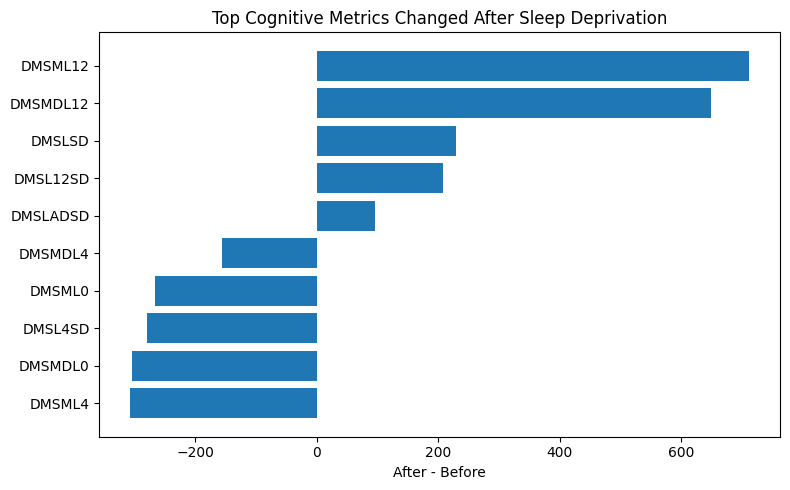

In [10]:
import matplotlib.pyplot as plt

top_diff = summary.head(10).sort_values('diff_after_minus_before')

plt.figure(figsize=(8, 5))
plt.barh(top_diff.index, top_diff['diff_after_minus_before'])
plt.xlabel('After - Before')
plt.title('Top Cognitive Metrics Changed After Sleep Deprivation')
plt.tight_layout()
plt.show()

In [11]:
paired = df[['subject_base', 'condition'] + feature_df.columns.tolist()].copy()

before_df = paired[paired['condition'] == 'before'].drop(columns=['condition'])
after_df = paired[paired['condition'] == 'after'].drop(columns=['condition'])

paired_delta = before_df.merge(after_df, on='subject_base', suffixes=('_before', '_after'))

print(paired_delta.shape)
paired_delta.head()

(10, 203)


,subject_base,DMSCC_before,DMSL0SD_before,DMSL12SD_before,DMSL4SD_before,DMSLADSD_before,DMSLSD_before,DMSLSSD_before,DMSMDL_before,DMSMDL0_before,...,SWMS_after,SWMS6_after,SWMTE_after,SWMTE4_after,SWMTE6_after,SWMTE8_after,SWMWE_after,SWMWE4_after,SWMWE6_after,SWMWE8_after
0,SUBJ001,1.00,647.7034,1082.0378,1519.8841,1106.1289,1068.9469,925.0485,2482.0,2465.0,...,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,SUBJ002,1.00,254.2214,1088.2416,1299.9392,971.1181,881.5461,571.6577,1925.5,2039.0,...,7.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,SUBJ003,1.00,412.0081,1584.2954,844.2390,1130.8034,1157.3070,1354.3067,2827.0,2875.0,...,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,SUBJ004,1.10,515.5343,294.7749,1774.9348,1109.1828,1095.6559,887.0709,3572.5,3841.5,...,8.0,6.0,8.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0
4,SUBJ005,1.05,476.0976,1081.0911,550.9879,758.0661,715.8888,464.5053,1882.0,1923.5,...,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Preliminary interpretation

This dataset contains cognitive test measurements collected before and after 24 hours of sleep deprivation. As a first step, the analysis tests whether CANTAB-derived cognitive metrics can distinguish baseline from sleep-deprived sessions.

In addition to classification, mean differences across conditions are examined to identify which cognitive measures appear most affected by sleep deprivation.

In [12]:
import pandas as pd
import numpy as np

paired = df[['subject_base', 'condition'] + feature_df.columns.tolist()].copy()

before_df = paired[paired['condition'] == 'before'].drop(columns=['condition'])
after_df = paired[paired['condition'] == 'after'].drop(columns=['condition'])

paired_df = before_df.merge(after_df, on='subject_base', suffixes=('_before', '_after'))

print("Paired subjects:", paired_df.shape[0])
paired_df.head()

Paired subjects: 10


,subject_base,DMSCC_before,DMSL0SD_before,DMSL12SD_before,DMSL4SD_before,DMSLADSD_before,DMSLSD_before,DMSLSSD_before,DMSMDL_before,DMSMDL0_before,...,SWMS_after,SWMS6_after,SWMTE_after,SWMTE4_after,SWMTE6_after,SWMTE8_after,SWMWE_after,SWMWE4_after,SWMWE6_after,SWMWE8_after
0,SUBJ001,1.00,647.7034,1082.0378,1519.8841,1106.1289,1068.9469,925.0485,2482.0,2465.0,...,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,SUBJ002,1.00,254.2214,1088.2416,1299.9392,971.1181,881.5461,571.6577,1925.5,2039.0,...,7.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,SUBJ003,1.00,412.0081,1584.2954,844.2390,1130.8034,1157.3070,1354.3067,2827.0,2875.0,...,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,SUBJ004,1.10,515.5343,294.7749,1774.9348,1109.1828,1095.6559,887.0709,3572.5,3841.5,...,8.0,6.0,8.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0
4,SUBJ005,1.05,476.0976,1081.0911,550.9879,758.0661,715.8888,464.5053,1882.0,1923.5,...,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
from scipy.stats import ttest_rel, wilcoxon, shapiro

def paired_test(before, after):
    tmp = pd.DataFrame({'before': before, 'after': after}).dropna()

    n = len(tmp)
    if n < 3:
        return {
            'n': n,
            'test_used': None,
            'statistic': np.nan,
            'p_value': np.nan,
            'mean_before': tmp['before'].mean() if n > 0 else np.nan,
            'mean_after': tmp['after'].mean() if n > 0 else np.nan,
            'mean_diff': (tmp['after'] - tmp['before']).mean() if n > 0 else np.nan,
            'std_diff': (tmp['after'] - tmp['before']).std(ddof=1) if n > 1 else np.nan,
            'effect_size_dz': np.nan,
            'normality_p': np.nan
        }

    diff = tmp['after'] - tmp['before']

    
    if n >= 3:
        normality_p = shapiro(diff).pvalue
    else:
        normality_p = np.nan

    mean_before = tmp['before'].mean()
    mean_after = tmp['after'].mean()
    mean_diff = diff.mean()
    std_diff = diff.std(ddof=1)

    
    effect_size_dz = mean_diff / std_diff if std_diff and not np.isclose(std_diff, 0) else np.nan

    
    if pd.notna(normality_p) and normality_p >= 0.05:
        stat, p = ttest_rel(tmp['after'], tmp['before'], nan_policy='omit')
        test_used = 'paired_t_test'
    else:
        try:
            stat, p = wilcoxon(tmp['after'], tmp['before'])
            test_used = 'wilcoxon'
        except ValueError:
            stat, p = np.nan, np.nan
            test_used = 'wilcoxon_failed'

    return {
        'n': n,
        'test_used': test_used,
        'statistic': stat,
        'p_value': p,
        'mean_before': mean_before,
        'mean_after': mean_after,
        'mean_diff': mean_diff,
        'std_diff': std_diff,
        'effect_size_dz': effect_size_dz,
        'normality_p': normality_p
    }

In [14]:
results = []
import warnings

warnings.filterwarnings(
    "ignore",
    message="scipy.stats.shapiro: Input data has range zero.*",
    category=UserWarning
)

for col in feature_df.columns:
    before_col = f"{col}_before"
    after_col = f"{col}_after"

    if before_col in paired_df.columns and after_col in paired_df.columns:
        res = paired_test(paired_df[before_col], paired_df[after_col])
        res["metric"] = col
        results.append(res)
        
for col in feature_df.columns:
    before_col = f'{col}_before'
    after_col = f'{col}_after'

    if before_col in paired_df.columns and after_col in paired_df.columns:
        res = paired_test(paired_df[before_col], paired_df[after_col])
        res['metric'] = col
        results.append(res)

paired_results_df = pd.DataFrame(results)

paired_results_df = paired_results_df.sort_values(['p_value', 'mean_diff'], ascending=[True, False])
paired_results_df.head(20)

,n,test_used,statistic,p_value,mean_before,mean_after,mean_diff,std_diff,effect_size_dz,normality_p,metric
81,9,wilcoxon,1.000000,0.007812,9.111111,15.666667,6.555556,7.986099,0.820871,0.021164,RVPTM
182,9,wilcoxon,1.000000,0.007812,9.111111,15.666667,6.555556,7.986099,0.820871,0.021164,RVPTM
73,9,wilcoxon,1.000000,0.007812,0.956989,0.925744,-0.031244,0.037820,-0.826138,0.019347,RVPA
174,9,wilcoxon,1.000000,0.007812,0.956989,0.925744,-0.031244,0.037820,-0.826138,0.019347,RVPA
78,9,wilcoxon,1.000000,0.007812,0.831267,0.709889,-0.121378,0.147871,-0.820835,0.021175,RVPPH
179,9,wilcoxon,1.000000,0.007812,0.831267,0.709889,-0.121378,0.147871,-0.820835,0.021175,RVPPH
80,9,wilcoxon,1.000000,0.007812,44.888889,38.333333,-6.555556,7.986099,-0.820871,0.021164,RVPTH
181,9,wilcoxon,1.000000,0.007812,44.888889,38.333333,-6.555556,7.986099,-0.820871,0.021164,RVPTH
71,10,wilcoxon,4.000000,0.013672,37.782150,58.210190,20.428040,26.863612,0.760435,0.019972,RTIFRTSD
172,10,wilcoxon,4.000000,0.013672,37.782150,58.210190,20.428040,26.863612,0.760435,0.019972,RTIFRTSD


In [15]:
from statsmodels.stats.multitest import multipletests

valid_mask = paired_results_df['p_value'].notna()

rej, p_adj, _, _ = multipletests(
    paired_results_df.loc[valid_mask, 'p_value'],
    method='fdr_bh'
)

paired_results_df.loc[valid_mask, 'p_value_fdr_bh'] = p_adj
paired_results_df.loc[valid_mask, 'significant_fdr_0_05'] = rej

paired_results_df = paired_results_df.sort_values('p_value_fdr_bh', ascending=True)
paired_results_df.head(20)

,n,test_used,statistic,p_value,mean_before,mean_after,mean_diff,std_diff,effect_size_dz,normality_p,metric,p_value_fdr_bh,significant_fdr_0_05
81,9,wilcoxon,1.000000,0.007812,9.111111,15.666667,6.555556,7.986099,0.820871,0.021164,RVPTM,0.162109,False
182,9,wilcoxon,1.000000,0.007812,9.111111,15.666667,6.555556,7.986099,0.820871,0.021164,RVPTM,0.162109,False
73,9,wilcoxon,1.000000,0.007812,0.956989,0.925744,-0.031244,0.037820,-0.826138,0.019347,RVPA,0.162109,False
174,9,wilcoxon,1.000000,0.007812,0.956989,0.925744,-0.031244,0.037820,-0.826138,0.019347,RVPA,0.162109,False
78,9,wilcoxon,1.000000,0.007812,0.831267,0.709889,-0.121378,0.147871,-0.820835,0.021175,RVPPH,0.162109,False
179,9,wilcoxon,1.000000,0.007812,0.831267,0.709889,-0.121378,0.147871,-0.820835,0.021175,RVPPH,0.162109,False
80,9,wilcoxon,1.000000,0.007812,44.888889,38.333333,-6.555556,7.986099,-0.820871,0.021164,RVPTH,0.162109,False
181,9,wilcoxon,1.000000,0.007812,44.888889,38.333333,-6.555556,7.986099,-0.820871,0.021164,RVPTH,0.162109,False
71,10,wilcoxon,4.000000,0.013672,37.782150,58.210190,20.428040,26.863612,0.760435,0.019972,RTIFRTSD,0.226953,False
172,10,wilcoxon,4.000000,0.013672,37.782150,58.210190,20.428040,26.863612,0.760435,0.019972,RTIFRTSD,0.226953,False


In [16]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [17]:
from statsmodels.stats.multitest import multipletests

In [18]:
from statsmodels.stats.multitest import multipletests

valid_mask = paired_results_df['p_value'].notna()

rej, p_adj, _, _ = multipletests(
    paired_results_df.loc[valid_mask, 'p_value'],
    method='fdr_bh'
)

paired_results_df.loc[valid_mask, 'p_value_fdr_bh'] = p_adj
paired_results_df.loc[valid_mask, 'significant_fdr_0_05'] = rej

paired_results_df = paired_results_df.sort_values('p_value_fdr_bh', ascending=True)
paired_results_df.head(20)

,n,test_used,statistic,p_value,mean_before,mean_after,mean_diff,std_diff,effect_size_dz,normality_p,metric,p_value_fdr_bh,significant_fdr_0_05
81,9,wilcoxon,1.000000,0.007812,9.111111,15.666667,6.555556,7.986099,0.820871,0.021164,RVPTM,0.162109,False
182,9,wilcoxon,1.000000,0.007812,9.111111,15.666667,6.555556,7.986099,0.820871,0.021164,RVPTM,0.162109,False
73,9,wilcoxon,1.000000,0.007812,0.956989,0.925744,-0.031244,0.037820,-0.826138,0.019347,RVPA,0.162109,False
174,9,wilcoxon,1.000000,0.007812,0.956989,0.925744,-0.031244,0.037820,-0.826138,0.019347,RVPA,0.162109,False
78,9,wilcoxon,1.000000,0.007812,0.831267,0.709889,-0.121378,0.147871,-0.820835,0.021175,RVPPH,0.162109,False
179,9,wilcoxon,1.000000,0.007812,0.831267,0.709889,-0.121378,0.147871,-0.820835,0.021175,RVPPH,0.162109,False
80,9,wilcoxon,1.000000,0.007812,44.888889,38.333333,-6.555556,7.986099,-0.820871,0.021164,RVPTH,0.162109,False
181,9,wilcoxon,1.000000,0.007812,44.888889,38.333333,-6.555556,7.986099,-0.820871,0.021164,RVPTH,0.162109,False
71,10,wilcoxon,4.000000,0.013672,37.782150,58.210190,20.428040,26.863612,0.760435,0.019972,RTIFRTSD,0.226953,False
172,10,wilcoxon,4.000000,0.013672,37.782150,58.210190,20.428040,26.863612,0.760435,0.019972,RTIFRTSD,0.226953,False


In [19]:
import numpy as np
import pandas as pd

from scipy.stats import ttest_rel, wilcoxon, shapiro
from statsmodels.stats.multitest import multipletests


if 'df' not in globals():
    raise NameError("df is not defined. Load and clean the SD_CANTAB_DB_public.csv file first.")

if 'feature_df' not in globals():
    raise NameError("feature_df is not defined. Run the feature selection/cleaning step first.")


paired = df[['subject_base', 'condition'] + feature_df.columns.tolist()].copy()

before_df = paired[paired['condition'] == 'before'].drop(columns=['condition'])
after_df = paired[paired['condition'] == 'after'].drop(columns=['condition'])

paired_df = before_df.merge(after_df, on='subject_base', suffixes=('_before', '_after'))

print("Paired subjects:", paired_df.shape[0])


def paired_test(before, after):
    tmp = pd.DataFrame({'before': before, 'after': after}).dropna()

    n = len(tmp)
    if n < 3:
        return {
            'n': n,
            'test_used': None,
            'statistic': np.nan,
            'p_value': np.nan,
            'mean_before': tmp['before'].mean() if n > 0 else np.nan,
            'mean_after': tmp['after'].mean() if n > 0 else np.nan,
            'mean_diff': (tmp['after'] - tmp['before']).mean() if n > 0 else np.nan,
            'std_diff': (tmp['after'] - tmp['before']).std(ddof=1) if n > 1 else np.nan,
            'effect_size_dz': np.nan,
            'normality_p': np.nan
        }

    diff = tmp['after'] - tmp['before']
    mean_before = tmp['before'].mean()
    mean_after = tmp['after'].mean()
    mean_diff = diff.mean()
    std_diff = diff.std(ddof=1)

    effect_size_dz = mean_diff / std_diff if pd.notna(std_diff) and not np.isclose(std_diff, 0) else np.nan

    if np.isclose(diff.std(ddof=1), 0):
        normality_p = np.nan

        if np.isclose(mean_diff, 0):
            return {
                'n': n,
                'test_used': 'constant_no_change',
                'statistic': 0.0,
                'p_value': 1.0,
                'mean_before': mean_before,
                'mean_after': mean_after,
                'mean_diff': mean_diff,
                'std_diff': std_diff,
                'effect_size_dz': 0.0,
                'normality_p': normality_p
            }
        else:
            return {
                'n': n,
                'test_used': 'constant_change',
                'statistic': np.nan,
                'p_value': np.nan,
                'mean_before': mean_before,
                'mean_after': mean_after,
                'mean_diff': mean_diff,
                'std_diff': std_diff,
                'effect_size_dz': np.nan,
                'normality_p': normality_p
            }

    normality_p = shapiro(diff).pvalue

    if normality_p >= 0.05:
        stat, p = ttest_rel(tmp['after'], tmp['before'], nan_policy='omit')
        test_used = 'paired_t_test'
    else:
        try:
            stat, p = wilcoxon(tmp['after'], tmp['before'])
            test_used = 'wilcoxon'
        except ValueError:
            stat, p = np.nan, np.nan
            test_used = 'wilcoxon_failed'

    return {
        'n': n,
        'test_used': test_used,
        'statistic': stat,
        'p_value': p,
        'mean_before': mean_before,
        'mean_after': mean_after,
        'mean_diff': mean_diff,
        'std_diff': std_diff,
        'effect_size_dz': effect_size_dz,
        'normality_p': normality_p
    }

results = []

for col in feature_df.columns:
    before_col = f'{col}_before'
    after_col = f'{col}_after'

    if before_col in paired_df.columns and after_col in paired_df.columns:
        res = paired_test(paired_df[before_col], paired_df[after_col])
        res['metric'] = col
        results.append(res)

paired_results_df = pd.DataFrame(results)

valid_mask = paired_results_df['p_value'].notna()

if valid_mask.sum() > 0:
    rej, p_adj, _, _ = multipletests(
        paired_results_df.loc[valid_mask, 'p_value'],
        method='fdr_bh'
    )
    paired_results_df.loc[valid_mask, 'p_value_fdr_bh'] = p_adj
    paired_results_df.loc[valid_mask, 'significant_fdr_0_05'] = rej
else:
    paired_results_df['p_value_fdr_bh'] = np.nan
    paired_results_df['significant_fdr_0_05'] = np.nan

paired_results_df = paired_results_df.sort_values(
    by=['p_value_fdr_bh', 'p_value'],
    ascending=[True, True],
    na_position='last'
)

summary_cols = [
    'metric',
    'n',
    'test_used',
    'mean_before',
    'mean_after',
    'mean_diff',
    'effect_size_dz',
    'p_value',
    'p_value_fdr_bh',
    'significant_fdr_0_05'
]

paired_summary = paired_results_df[summary_cols].copy()

print("paired_df shape:", paired_df.shape)
print("paired_results_df shape:", paired_results_df.shape)

display(paired_summary.head(20))

Paired subjects: 10
paired_df shape: (10, 203)
paired_results_df shape: (101, 13)


,metric,n,test_used,mean_before,mean_after,mean_diff,effect_size_dz,p_value,p_value_fdr_bh,significant_fdr_0_05
73,RVPA,9,wilcoxon,0.956989,0.925744,-0.031244,-0.826138,0.007812,0.197266,False
78,RVPPH,9,wilcoxon,0.831267,0.709889,-0.121378,-0.820835,0.007812,0.197266,False
80,RVPTH,9,wilcoxon,44.888889,38.333333,-6.555556,-0.820871,0.007812,0.197266,False
81,RVPTM,9,wilcoxon,9.111111,15.666667,6.555556,0.820871,0.007812,0.197266,False
71,RTIFRTSD,10,wilcoxon,37.782150,58.210190,20.428040,0.760435,0.013672,0.276172,False
68,RTIFMMT,10,paired_t_test,247.279530,291.862240,44.582710,0.882391,0.021041,0.354194,False
66,RTIFMDMT,10,paired_t_test,244.300000,286.650000,42.350000,0.830285,0.027557,0.397609,False
69,RTIFMRT,10,paired_t_test,341.199540,378.462430,37.262890,0.792563,0.033513,0.423106,False
67,RTIFMDRT,10,paired_t_test,333.700000,367.350000,33.650000,0.736704,0.044772,0.496184,False
70,RTIFMTSD,10,paired_t_test,33.543750,48.391720,14.847970,0.693938,0.055846,0.496184,False


In [20]:
df_clean = df.copy()

drop_cols = ["Unnamed: 108", "Unnamed: 110", "Notes"]
drop_cols = [col for col in drop_cols if col in df_clean.columns]
df_clean = df_clean.drop(columns=drop_cols)

df_clean["condition"] = df_clean["Subject ID"].str.extract(r"_(before|after)$")[0]
df_clean["sleep_deprived"] = (df_clean["condition"] == "after").astype(int)
df_clean["subject_base"] = df_clean["Subject ID"].str.replace(
    r"_(before|after)$",
    "",
    regex=True
)

print(df_clean.shape)

df_clean[["Subject ID", "subject_base", "condition", "sleep_deprived"]].head()

(21, 111)


,Subject ID,subject_base,condition,sleep_deprived
0,SUBJ001_before,SUBJ001,before,0
1,SUBJ002_before,SUBJ002,before,0
2,SUBJ003_before,SUBJ003,before,0
3,SUBJ004_before,SUBJ004,before,0
4,SUBJ005_before,SUBJ005,before,0


In [21]:
status_cols = [c for c in df.columns if 'Status' in c]
non_feature_cols = ['Subject ID', 'condition', 'sleep_deprived', 'subject_base']

feature_df = df.drop(columns=status_cols + [c for c in non_feature_cols if c in df.columns], errors='ignore')
feature_df = feature_df.apply(pd.to_numeric, errors='coerce')

print(feature_df.shape)
feature_df.head()

(21, 101)


,DMSCC,DMSL0SD,DMSL12SD,DMSL4SD,DMSLADSD,DMSLSD,DMSLSSD,DMSMDL,DMSMDL0,DMSMDL12,...,SWMS,SWMS6,SWMTE,SWMTE4,SWMTE6,SWMTE8,SWMWE,SWMWE4,SWMWE6,SWMWE8
0,1.00,647.7034,1082.0378,1519.8841,1106.1289,1068.9469,925.0485,2482.0,2465.0,3007.0,...,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.00,254.2214,1088.2416,1299.9392,971.1181,881.5461,571.6577,1925.5,2039.0,1446.0,...,7.0,3.0,6.0,0.0,0.0,6.0,2.0,0.0,0.0,2.0
2,1.00,412.0081,1584.2954,844.2390,1130.8034,1157.3070,1354.3067,2827.0,2875.0,3256.0,...,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.10,515.5343,294.7749,1774.9348,1109.1828,1095.6559,887.0709,3572.5,3841.5,3818.5,...,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.05,476.0976,1081.0911,550.9879,758.0661,715.8888,464.5053,1882.0,1923.5,2273.0,...,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [22]:
import numpy as np
import pandas as pd

from scipy.stats import ttest_rel, wilcoxon, shapiro
from statsmodels.stats.multitest import multipletests


if 'df' not in globals():
    raise NameError("df is not defined. Load and clean the SD_CANTAB_DB_public.csv file first.")

if 'feature_df' not in globals():
    raise NameError("feature_df is not defined. Run the feature selection/cleaning step first.")


paired = df[['subject_base', 'condition'] + feature_df.columns.tolist()].copy()

before_df = paired[paired['condition'] == 'before'].drop(columns=['condition'])
after_df = paired[paired['condition'] == 'after'].drop(columns=['condition'])

paired_df = before_df.merge(after_df, on='subject_base', suffixes=('_before', '_after'))

print("Paired subjects:", paired_df.shape[0])

def paired_test(before, after):
    tmp = pd.DataFrame({'before': before, 'after': after}).dropna()

    n = len(tmp)
    if n < 3:
        return {
            'n': n,
            'test_used': None,
            'statistic': np.nan,
            'p_value': np.nan,
            'mean_before': tmp['before'].mean() if n > 0 else np.nan,
            'mean_after': tmp['after'].mean() if n > 0 else np.nan,
            'mean_diff': (tmp['after'] - tmp['before']).mean() if n > 0 else np.nan,
            'std_diff': (tmp['after'] - tmp['before']).std(ddof=1) if n > 1 else np.nan,
            'effect_size_dz': np.nan,
            'normality_p': np.nan
        }

    diff = tmp['after'] - tmp['before']
    mean_before = tmp['before'].mean()
    mean_after = tmp['after'].mean()
    mean_diff = diff.mean()
    std_diff = diff.std(ddof=1)

    effect_size_dz = mean_diff / std_diff if pd.notna(std_diff) and not np.isclose(std_diff, 0) else np.nan

    if np.isclose(diff.std(ddof=1), 0):
        normality_p = np.nan

        if np.isclose(mean_diff, 0):
            return {
                'n': n,
                'test_used': 'constant_no_change',
                'statistic': 0.0,
                'p_value': 1.0,
                'mean_before': mean_before,
                'mean_after': mean_after,
                'mean_diff': mean_diff,
                'std_diff': std_diff,
                'effect_size_dz': 0.0,
                'normality_p': normality_p
            }
        else:
            return {
                'n': n,
                'test_used': 'constant_change',
                'statistic': np.nan,
                'p_value': np.nan,
                'mean_before': mean_before,
                'mean_after': mean_after,
                'mean_diff': mean_diff,
                'std_diff': std_diff,
                'effect_size_dz': np.nan,
                'normality_p': normality_p
            }

    normality_p = shapiro(diff).pvalue

    if normality_p >= 0.05:
        stat, p = ttest_rel(tmp['after'], tmp['before'], nan_policy='omit')
        test_used = 'paired_t_test'
    else:
        try:
            stat, p = wilcoxon(tmp['after'], tmp['before'])
            test_used = 'wilcoxon'
        except ValueError:
            stat, p = np.nan, np.nan
            test_used = 'wilcoxon_failed'

    return {
        'n': n,
        'test_used': test_used,
        'statistic': stat,
        'p_value': p,
        'mean_before': mean_before,
        'mean_after': mean_after,
        'mean_diff': mean_diff,
        'std_diff': std_diff,
        'effect_size_dz': effect_size_dz,
        'normality_p': normality_p
    }


results = []

for col in feature_df.columns:
    before_col = f'{col}_before'
    after_col = f'{col}_after'

    if before_col in paired_df.columns and after_col in paired_df.columns:
        res = paired_test(paired_df[before_col], paired_df[after_col])
        res['metric'] = col
        results.append(res)

paired_results_df = pd.DataFrame(results)

valid_mask = paired_results_df['p_value'].notna()

if valid_mask.sum() > 0:
    rej, p_adj, _, _ = multipletests(
        paired_results_df.loc[valid_mask, 'p_value'],
        method='fdr_bh'
    )
    paired_results_df.loc[valid_mask, 'p_value_fdr_bh'] = p_adj
    paired_results_df.loc[valid_mask, 'significant_fdr_0_05'] = rej
else:
    paired_results_df['p_value_fdr_bh'] = np.nan
    paired_results_df['significant_fdr_0_05'] = np.nan

paired_results_df = paired_results_df.sort_values(
    by=['p_value_fdr_bh', 'p_value'],
    ascending=[True, True],
    na_position='last'
)

summary_cols = [
    'metric',
    'n',
    'test_used',
    'mean_before',
    'mean_after',
    'mean_diff',
    'effect_size_dz',
    'p_value',
    'p_value_fdr_bh',
    'significant_fdr_0_05'
]

paired_summary = paired_results_df[summary_cols].copy()

print("paired_df shape:", paired_df.shape)
print("paired_results_df shape:", paired_results_df.shape)

display(paired_summary.head(20))

Paired subjects: 10
paired_df shape: (10, 203)
paired_results_df shape: (101, 13)


,metric,n,test_used,mean_before,mean_after,mean_diff,effect_size_dz,p_value,p_value_fdr_bh,significant_fdr_0_05
73,RVPA,9,wilcoxon,0.956989,0.925744,-0.031244,-0.826138,0.007812,0.197266,False
78,RVPPH,9,wilcoxon,0.831267,0.709889,-0.121378,-0.820835,0.007812,0.197266,False
80,RVPTH,9,wilcoxon,44.888889,38.333333,-6.555556,-0.820871,0.007812,0.197266,False
81,RVPTM,9,wilcoxon,9.111111,15.666667,6.555556,0.820871,0.007812,0.197266,False
71,RTIFRTSD,10,wilcoxon,37.782150,58.210190,20.428040,0.760435,0.013672,0.276172,False
68,RTIFMMT,10,paired_t_test,247.279530,291.862240,44.582710,0.882391,0.021041,0.354194,False
66,RTIFMDMT,10,paired_t_test,244.300000,286.650000,42.350000,0.830285,0.027557,0.397609,False
69,RTIFMRT,10,paired_t_test,341.199540,378.462430,37.262890,0.792563,0.033513,0.423106,False
67,RTIFMDRT,10,paired_t_test,333.700000,367.350000,33.650000,0.736704,0.044772,0.496184,False
70,RTIFMTSD,10,paired_t_test,33.543750,48.391720,14.847970,0.693938,0.055846,0.496184,False


In [23]:
paired_results_df.sort_values('effect_size_dz', key=lambda s: s.abs(), ascending=False).head(20)

,n,test_used,statistic,p_value,mean_before,mean_after,mean_diff,std_diff,effect_size_dz,normality_p,metric,p_value_fdr_bh,significant_fdr_0_05
26,3,paired_t_test,1.941489,0.191704,0.000000,0.194433,0.194433,0.173459,1.120919,0.463110,DMSPEGE,0.605066,False
68,10,paired_t_test,2.790367,0.021041,247.279530,291.862240,44.582710,50.524866,0.882391,0.072589,RTIFMMT,0.354194,False
21,10,wilcoxon,0.000000,0.062500,94.000000,80.000000,-14.000000,16.465452,-0.850265,0.008500,DMSPC12,0.496184,False
29,10,wilcoxon,0.000000,0.062500,4.700000,4.000000,-0.700000,0.823273,-0.850265,0.008500,DMSTC12,0.496184,False
66,10,paired_t_test,2.625593,0.027557,244.300000,286.650000,42.350000,51.006563,0.830285,0.224759,RTIFMDMT,0.397609,False
73,9,wilcoxon,1.000000,0.007812,0.956989,0.925744,-0.031244,0.037820,-0.826138,0.019347,RVPA,0.197266,False
80,9,wilcoxon,1.000000,0.007812,44.888889,38.333333,-6.555556,7.986099,-0.820871,0.021164,RVPTH,0.197266,False
81,9,wilcoxon,1.000000,0.007812,9.111111,15.666667,6.555556,7.986099,0.820871,0.021164,RVPTM,0.197266,False
78,9,wilcoxon,1.000000,0.007812,0.831267,0.709889,-0.121378,0.147871,-0.820835,0.021175,RVPPH,0.197266,False
69,10,paired_t_test,2.506304,0.033513,341.199540,378.462430,37.262890,47.015688,0.792563,0.431378,RTIFMRT,0.423106,False


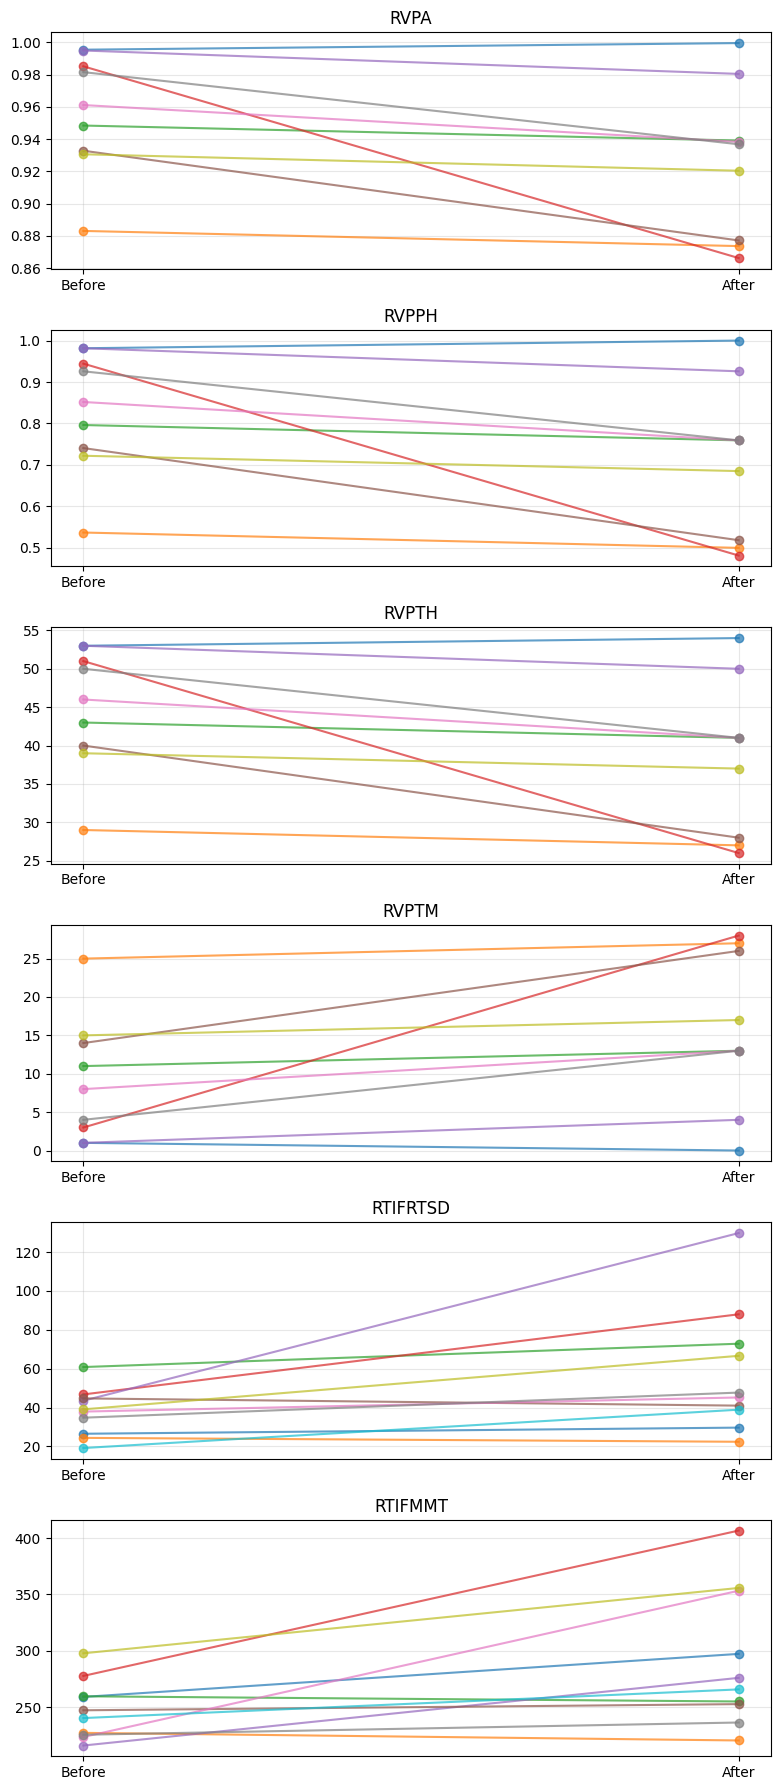

In [24]:
import matplotlib.pyplot as plt

top_metrics = (
    paired_results_df
    .sort_values('p_value', ascending=True)
    .head(6)['metric']
    .tolist()
)

fig, axes = plt.subplots(len(top_metrics), 1, figsize=(8, 3 * len(top_metrics)))

if len(top_metrics) == 1:
    axes = [axes]

for ax, metric in zip(axes, top_metrics):
    before_col = f'{metric}_before'
    after_col = f'{metric}_after'

    tmp = paired_df[['subject_base', before_col, after_col]].dropna()

    for _, row in tmp.iterrows():
        ax.plot(['Before', 'After'], [row[before_col], row[after_col]], marker='o', alpha=0.7)

    ax.set_title(metric)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

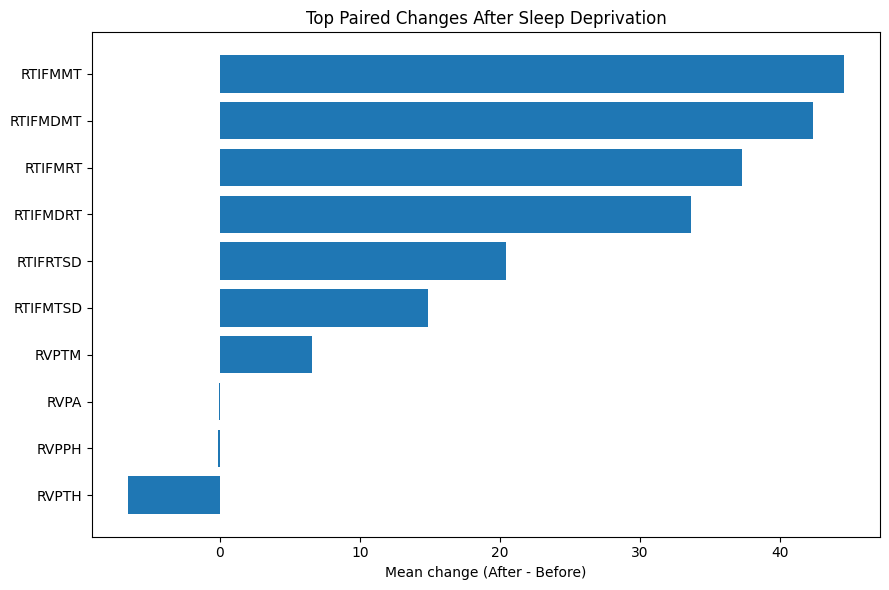

In [25]:
top10 = paired_results_df.nsmallest(10, 'p_value').copy()
top10 = top10.sort_values('mean_diff')

plt.figure(figsize=(9, 6))
plt.barh(top10['metric'], top10['mean_diff'])
plt.xlabel('Mean change (After - Before)')
plt.title('Top Paired Changes After Sleep Deprivation')
plt.tight_layout()
plt.show()

In [26]:
summary_cols = [
    'metric',
    'n',
    'test_used',
    'mean_before',
    'mean_after',
    'mean_diff',
    'effect_size_dz',
    'p_value',
    'p_value_fdr_bh',
    'significant_fdr_0_05'
]

paired_summary = paired_results_df[summary_cols].copy()
paired_summary.head(20)

,metric,n,test_used,mean_before,mean_after,mean_diff,effect_size_dz,p_value,p_value_fdr_bh,significant_fdr_0_05
73,RVPA,9,wilcoxon,0.956989,0.925744,-0.031244,-0.826138,0.007812,0.197266,False
78,RVPPH,9,wilcoxon,0.831267,0.709889,-0.121378,-0.820835,0.007812,0.197266,False
80,RVPTH,9,wilcoxon,44.888889,38.333333,-6.555556,-0.820871,0.007812,0.197266,False
81,RVPTM,9,wilcoxon,9.111111,15.666667,6.555556,0.820871,0.007812,0.197266,False
71,RTIFRTSD,10,wilcoxon,37.782150,58.210190,20.428040,0.760435,0.013672,0.276172,False
68,RTIFMMT,10,paired_t_test,247.279530,291.862240,44.582710,0.882391,0.021041,0.354194,False
66,RTIFMDMT,10,paired_t_test,244.300000,286.650000,42.350000,0.830285,0.027557,0.397609,False
69,RTIFMRT,10,paired_t_test,341.199540,378.462430,37.262890,0.792563,0.033513,0.423106,False
67,RTIFMDRT,10,paired_t_test,333.700000,367.350000,33.650000,0.736704,0.044772,0.496184,False
70,RTIFMTSD,10,paired_t_test,33.543750,48.391720,14.847970,0.693938,0.055846,0.496184,False


## Paired analysis interpretation

The paired before-vs-after analysis revealed the strongest exploratory changes in RVP- and RTI-related cognitive metrics after 24 hours of sleep deprivation.

Although no metric remained significant after FDR correction, several raw p-values and within-subject effect sizes suggested consistent changes in sustained attention and reaction-time performance. In particular, RVP-related accuracy/hit measures decreased after sleep deprivation, while several RTI timing-related measures increased, indicating slower cognitive-motor responses.

Given the small sample size, these findings should be interpreted as exploratory but directionally informative.

In [27]:
paired_summary.to_csv(PROCESSED_DIR / 'paired_summary.csv', index=False)
paired_results_df.to_csv(PROCESSED_DIR / 'paired_results_df.csv', index=False)

print('Saved: paired_summary.csv')
print('Saved: paired_results_df.csv')

Saved: paired_summary.csv
Saved: paired_results_df.csv


In [28]:
paired_summary.to_csv(PROCESSED_DIR / 'paired_summary.csv', index=False)
paired_results_df.to_csv(PROCESSED_DIR / 'paired_results_df.csv', index=False)

print('Saved:', PROCESSED_DIR / 'paired_summary.csv')
print('Saved:', PROCESSED_DIR / 'paired_results_df.csv')

Saved: C:\Users\vi\Sleep-clean\data\processed\paired_summary.csv
Saved: C:\Users\vi\Sleep-clean\data\processed\paired_results_df.csv


## Conclusion

The public CANTAB sleep deprivation dataset was loaded and analyzed.  
Basic comparisons and summary results were prepared to explore how sleep deprivation may relate to cognitive performance outcomes.